# Ensemble Kaggle branch

In this notebook we process te image input and train an ensemble model with 
different arquitectures

In [20]:
# --- Imports & config ---
from pathlib import Path
import numpy as np
import pandas as pd
import torch.nn as nn
import timm
import os
import copy
import matplotlib.pyplot as plt
import time, torch
from torch.utils.data import WeightedRandomSampler, DataLoader
from tqdm import tqdm
from torch import amp
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import sys
sys.path.append("../utils")
from utils import create_balanced_split , ISIC_Multimodal_Dataset

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Paths (adjust if needed)
DATA_DIR = Path("../data")
MODELS_DIR = Path("../models")
TRAIN_META_CSV = DATA_DIR / "train-metadata.csv"
TEST_META_CSV  = DATA_DIR / "test-metadata.csv"
TRAIN_H5_PATH  = DATA_DIR / "train-image.hdf5"
TEST_H5_PATH   = DATA_DIR / "test-image.hdf5"

# Columns
ID_COL      = "isic_id"
TARGET_COL  = "target"
GROUP_COL   = "patient_id"

RANDOM_STATE = 42
N_SPLITS = 5

print(TRAIN_META_CSV.resolve())
print(TRAIN_H5_PATH.resolve())

Using device: cuda
/home/pawn/Desktop/deep_learning/ISIC_DL/data/train-metadata.csv
/home/pawn/Desktop/deep_learning/ISIC_DL/data/train-image.hdf5


## Load and analyze the data

Because of the extreme class imbalance in the dataset (approximately 0.01 vs 99.99), we follow two strategies. First, we limit the ratio of healthy lesions included during training: instead of using the full 400,000 benign images, we use a controlled ratio of 25 benign samples per malignant sample. Second, we apply targeted data augmentation to malignant class (class 1) examples to increase their effective variability and reduce overfitting.

For class 1 (malignant lesions), we apply medically appropriate augmentations inspired by the recommendations in Mahbod et al., *"Effects of augmentation strategies on skin lesion classification"* (2019). Their study demonstrates that carefully selected geometric and photometric transformations improve melanoma classification performance while avoiding unrealistic distortions.

Below is a summary of the augmentation pipeline used in this work.

### Data Augmentation for Skin Lesion Classification (ISIC)

To improve model generalization in skin lesion classification, we apply a set of medically validated data augmentations. These transformations simulate real-world acquisition variability, including differences in camera systems, zoom levels, lighting conditions, focus, rotation, and minor occlusions such as hair or ruler marks.

A brief explanation of each augmentation follows.

1. Resize → RandomResizedCrop
Images are first resized for consistent input dimensions. A random crop (90%–100% of the area) is then extracted.
*Purpose*: Simulates variation in zoom and framing across dermoscopy systems.


2. Random Rotation (±15°)
Applies small rotations without distorting the lesion structure.
*Purpose*: Lesions do not have a fixed orientation; rotation increases representation diversity.


3. Horizontal Flip
Mirrors the image horizontally.
*Purpose*: Human anatomy is largely symmetric; lesion appearance remains valid under flipping.


4. ColorJitter
Applies light variations in brightness, contrast, saturation, and hue.
*Purpose*: Models differences across dermatoscopes, lighting conditions, and skin tones.

5. RandomAdjustSharpness
Applies slight sharpening at random.
*Purpose*: Simulates variability in optical focus and imaging quality.

6. Gaussian Blur
Adds small blur variations.
*Purpose*: Reproduces the behavior of different dermoscopic camera systems.

7. RandomErasing
Erases a small random region of the image.
*Purpose*: Simulates occlusions such as hair, bubbles, ruler artifacts, or pen marks.

8. Normalize (ImageNet mean/std)
Standard normalization used with ImageNet-pretrained CNNs.

#### Scientific Support

These augmentations are supported by dermatology-focused studies, particularly:

**Mahbod et al., "Effects of augmentation strategies on skin lesion classification" (2019)**  
This work shows that:
- light geometric transformations,  
- controlled color perturbations,  
- blur and sharpness adjustments,  
- and occlusion-based augmentations  
consistently improve melanoma classification accuracy across ISIC datasets.

Link: https://arxiv.org/abs/1910.05351

---

Together, these augmentations increase robustness, reduce overfitting, and help compensate for the limited number of malignant samples in the dataset.


In [21]:
import torchvision.transforms as T
from torchvision.transforms import InterpolationMode


class DermoscopyAugmentation:
    """
    Scientific-grade augmentation pipeline for skin lesion classification.
    Designed based on augmentation strategies validated in ISIC Challenge papers.
    """

    @staticmethod
    def get_dataAugmentation_transforms():
        """Training augmentations (medically validated)"""
        return T.Compose([
            # --- Spatial ---
            T.Resize(256),
            T.RandomResizedCrop(224, scale=(0.9, 1.0), ratio=(0.9, 1.1)),
            T.RandomRotation(15, interpolation=InterpolationMode.BILINEAR),
            T.RandomHorizontalFlip(p=0.5),

            # --- Photometric ---
            T.ColorJitter(
                brightness=0.15,
                contrast=0.15,
                saturation=0.1,
                hue=0.02
            ),
            T.RandomAdjustSharpness(sharpness_factor=1.5, p=0.3),
            T.GaussianBlur(kernel_size=3, sigma=(0.1, 1.5)),

        ])

    @staticmethod
    def get_training_transforms():
        """Aggressive but medically-sound training augmentations"""
        return T.Compose([
            T.Resize((256, 256)),
            # spatial – conservative
            T.RandomResizedCrop(224, scale=(0.85, 1.0), ratio=(0.9, 1.1)),
            T.RandomRotation(20),
            T.RandomHorizontalFlip(p=0.5),

            # color – medically safe range
            T.ColorJitter(
                brightness=0.1,
                contrast=0.1,
                saturation=0.05,
                hue=0.02
            ),

            T.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0)),

            T.ToTensor(),
            T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),

            # optional but ok
            T.RandomErasing(p=0.05, scale=(0.01, 0.05), ratio=(0.3, 3.3)),
        ])
    
    @staticmethod
    def get_validation_transforms():
        """Conservative validation transforms"""
        return T.Compose([
            T.Resize((224, 224)),
            T.ToTensor(),
            T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])

In [22]:
from utils import get_best_metadata, MetadataProcessor

# 1º Create a split of train and validation balanced
# we dont need all the images
NEG_RATIO = 20      # 25:1
train_df, val_df, df_balanced = create_balanced_split(
    TRAIN_META_CSV,
    neg_multiplier=NEG_RATIO,      # conservative ratio of 25:1 
    val_frac=0.2            # split a 20% of train to validation
)

# 2º Create the augmented test and validation datasets trasforming the data
# with the following methods

augmentation_trans = DermoscopyAugmentation.get_dataAugmentation_transforms()
base_trans = DermoscopyAugmentation.get_training_transforms()
validation_trans = DermoscopyAugmentation.get_training_transforms()

# get the best metadata features analized with PCA common between test and train
test_df = pd.read_csv(TEST_META_CSV)
best_features = get_best_metadata(train_df, test_df, num_feat=50, verbose=True)
metadata_processor = MetadataProcessor(best_features)
metadata_processor.fit(pd.read_csv(TRAIN_META_CSV))

train_dataset = ISIC_Multimodal_Dataset(
    hdf5_path=TRAIN_H5_PATH,
    metadata_df=train_df,
    data_augmentation_trans=augmentation_trans,
    image_transform=base_trans,
    augment_positives=True,
    metadata_processor=metadata_processor
)

val_dataset = ISIC_Multimodal_Dataset(
    hdf5_path=TRAIN_H5_PATH,
    metadata_df=val_df,
    image_transform=validation_trans,
    metadata_processor=metadata_processor
)

test_dataset = ISIC_Multimodal_Dataset(
    hdf5_path=TEST_H5_PATH,
    metadata_df=test_df,
    image_transform=validation_trans,
    metadata_processor=metadata_processor
)

/home/pawn/Desktop/deep_learning/ISIC_DL/src/../utils/utils.py:60: DtypeWarning: Columns (51,52) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(metadataCSV_path)


Positives: 343
Negatives available: 400616
Negatives to sample: 6860

Balanced dataset size: 7203
target
0    6860
1     343
Name: count, dtype: int64

✔ Using all metadata features


/tmp/ipykernel_4339/3886635101.py:23: DtypeWarning: Columns (51,52) have mixed types. Specify dtype option on import or set low_memory=False.
  metadata_processor.fit(pd.read_csv(TRAIN_META_CSV))
/home/pawn/Desktop/deep_learning/ISIC_DL/src/../utils/utils.py:392: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  dummies[col] = 0
/home/pawn/Desktop/deep_learning/ISIC_DL/src/../utils/utils.py:392: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  dummies[col] = 0
/home/pawn/Desktop/deep_learning/ISIC_DL/src/../utils/utils.py:392: Performa

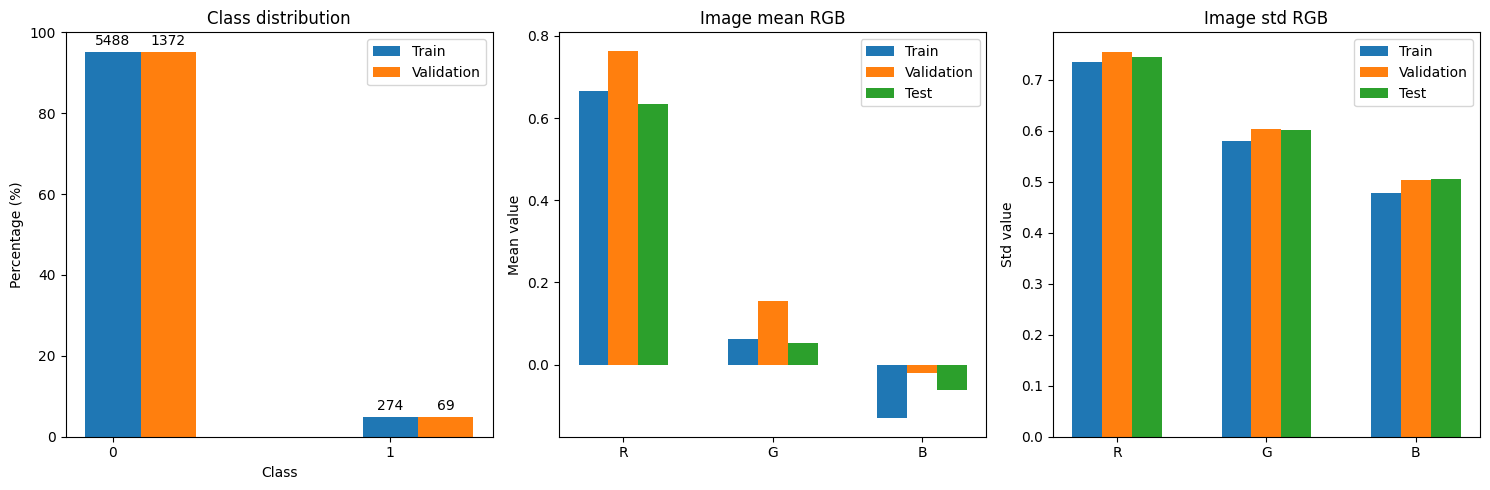

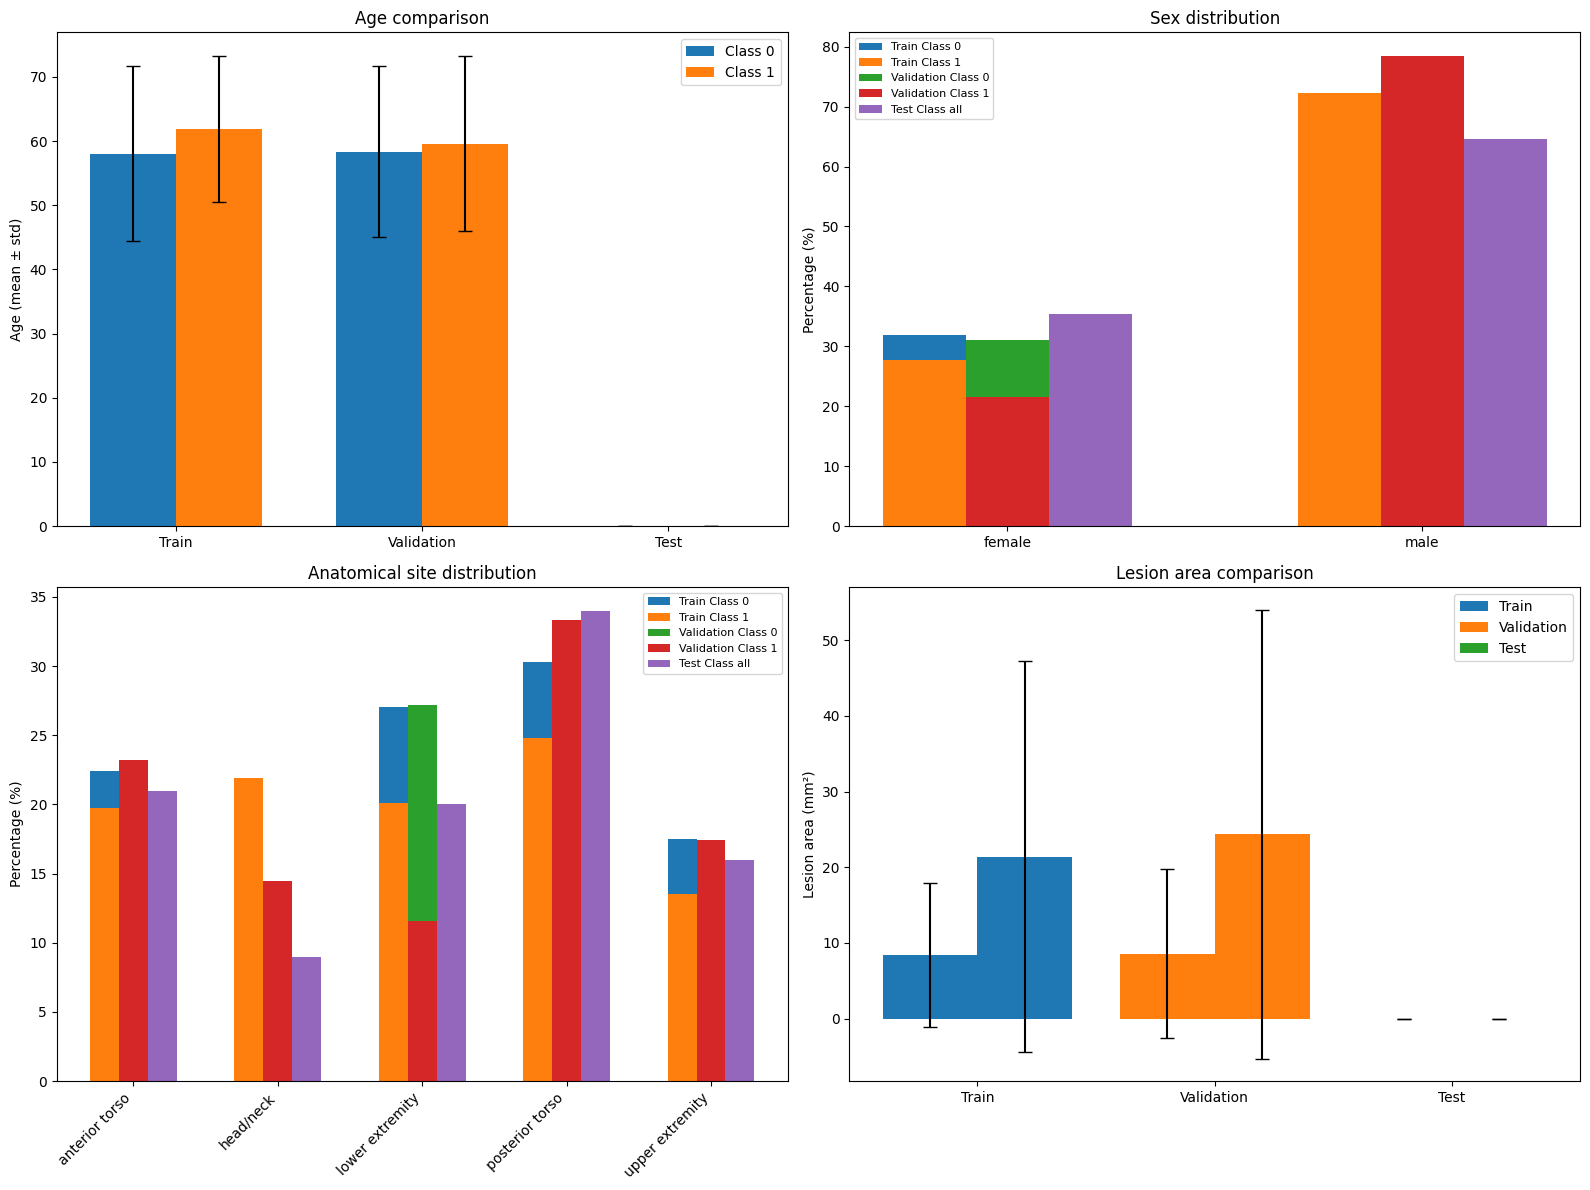

In [23]:
from utils import plot_stats

train_stats = train_dataset.get_dataset_stats(sample_size=300)
val_stats   = val_dataset.get_dataset_stats(sample_size=300)
test_stats  = test_dataset.get_dataset_stats(sample_size=300)
stats_list = [train_stats, val_stats, test_stats]

# Now we compare the analisis of the splits
plot_stats(stats_list)

## DataLoaders

We calculate the **ratio of the weighted sampler** using the formula:
$$
w_{c1}=\frac{p_{target}}{1-p_{target}}\frac{n_{c1}}{n_{c2}}
$$
so in the example we want $ p_{target} = 0.25 $
$$
w_{c1}=\frac{0.25}{0.75}\frac{20}{1}
$$

For the weights of the loss functions is as follows:
$$
pos_w=\frac{1-p_{posImg}}{p_{posImg}}
$$

In [24]:
def make_sampler_weights(targets, p_target):
    n_pos = (targets == 1).sum()
    n_neg = (targets == 0).sum()
    # sampler class weights (w_neg=1)
    w_pos = (p_target / (1 - p_target)) * (n_neg / n_pos)
    class_weights = np.array([1.0, w_pos], dtype=float)
    sample_weights = np.array([class_weights[int(t)] for t in targets], dtype=float)
    
    return sample_weights

In [25]:
from utils import PositiveOversampler
BATCH_SIZE = 16
NUM_IMGS_BATCH = 3000

# Get the weights for the sampler and the BCE loss fucntion
p_target = 0.5
multimodal_train_targets = train_dataset.metadata['target'].values
sample_weights = make_sampler_weights(multimodal_train_targets, p_target)

# Create the weighted sampler with the calculated weights
multimodal_weighted_sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=NUM_IMGS_BATCH,
    replacement=True
)

# pos_oversampler = PositiveOversampler(train_dataset, pos_multiplier=4)

# Create data loaders
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=multimodal_weighted_sampler,    # pos_oversampler,
    num_workers=4,
    pin_memory=True if device.type == 'cuda' else False
)

valid_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True if device.type == 'cuda' else False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True if device.type == 'cuda' else False
)

print("📦 Multimodal data loaders created with balanced sampling!")


📦 Multimodal data loaders created with balanced sampling!


# Backbone

In [26]:
class MetadataMLP(nn.Module):
    def __init__(self, in_features, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_features, hidden),
            nn.ReLU(),
            nn.BatchNorm1d(hidden),
            nn.Dropout(0.2),

            nn.Linear(hidden, hidden//2),
            nn.ReLU(),
            nn.BatchNorm1d(hidden//2),
            nn.Dropout(0.2),
        )
        self.out_dim = hidden//2

    def forward(self, x):
        return self.net(x)


class PretrainedClassifier(nn.Module):
    def __init__(self, model_name, metadata_dim, num_classes=1, pretrained=True):
        super().__init__()
        # Backbone for the image
        self.backbone = timm.create_model(
            model_name,
            pretrained=pretrained,
            num_classes=0  # don't use the original detection head
        )

        # Dummy input to get the real dimension of backbone output
        with torch.no_grad():
            dummy_img = torch.zeros(1, 3, 224, 224)  # ajustar tamaño según tu input
            img_feat = self.backbone(dummy_img)
        
        # MLP for the metadata
        self.meta_mlp = MetadataMLP(metadata_dim)
        
        # Mix both process
        fusion_dim = img_feat.shape[1] + self.meta_mlp.out_dim
        
        # Final head combining both data
        self.head = nn.Sequential(
            nn.Linear(fusion_dim, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, image, meta):
        # Image processed by Backbone
        img_feat = self.backbone(image)

        # Metadata processed by MLP
        meta_feat = self.meta_mlp(meta)
        # mix and pass to the head
        fused = torch.cat([img_feat, meta_feat], dim=1)
        out = self.head(fused)
        return out

class EnsembleClassifier(nn.Module):
    def __init__(self, models, hidden_dim=64):

        # Freeze base models
        self.models = nn.ModuleList(models)
        for m in self.models:
            for p in m.parameters():
                p.requires_grad = False
            m.eval()

        # get the number and propierties of models
        self.num_models = len(models)
        meta_input_dim = self.num_models  # logits if the model

        # ------------ Meta-model ("stacker") ----------------
        self.meta_model = nn.Sequential(
            nn.Linear(meta_input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim, 1)
        )

    # ---------------------------------------------------------
    def forward(self, image, metadata=None):

        # The otuputs of each model don't backpropagate
        with torch.no_grad():
            base_logits = []
            for m in self.models:
                logit = m(image, metadata)      # (batch, 1)
                base_logits.append(logit)

        # concatenate the logits: shape → (batch, num_models)
        base_logits = torch.cat(base_logits, dim=1)

        # Process the model
        out = self.meta_model(base_logits)
        return out

### Now we wrap the ensemble and models with a train function

In [27]:
from utils import TrainableModule

class PretrainedClassifierExtended(PretrainedClassifier, TrainableModule):
    def __init__(self, model_name, metadata_dim, criterion, device=device,
                 patience=5, min_delta=0.01):
        PretrainedClassifier.__init__(self, model_name, metadata_dim)
        TrainableModule.__init__(self, criterion, device, patience, min_delta)

        self.name = model_name

        # metrics
        self.history = {
            "train_loss": [],
            "val_loss": [],
            "val_auc": []
        }

    def fit(self, train_loader, val_loader=None, epochs=10):
        print(f"----------------------------------------")
        print(f"       Training {self.name}")
        print(f"----------------------------------------")
        for epoch in range(1, epochs+1):
            torch.cuda.empty_cache()
            torch.cuda.synchronize()
            start = time.time()
            print(f"Epoch {epoch}/{epochs}: ", end="")

            train_loss, per_pos = self._train_epoch(train_loader)
            self.history["train_loss"].append(train_loss)
            print(f"Train loss: {train_loss:.4f} || percentaje pos in epoch: {per_pos}%")

            if val_loader:
                val_loss, val_auc = self._validate(val_loader)
                self.history["val_loss"].append(val_loss)
                self.history["val_auc"].append(val_auc)
                print(f"Val Loss: {val_loss:.4f} | AUC: {val_auc:.4f}", end="")

                # save the best arquitecture
                if self.best_model_AUC < val_auc:
                    self.best_model_AUC = val_auc
                    self.best_model = copy.deepcopy(self.state_dict())

                if self._check_early_stopping(val_loss):
                    self.load_state_dict(self.best_state_dict)
                    self.to(self.device)
                    return  # exit for early stopping
                
            torch.cuda.synchronize()
            print(f" in {time.time() - start:.2f}s")
    
    @classmethod
    def load(cls, path, model_name, metadata_dim, criterion, device):
        model = cls(model_name, metadata_dim, criterion, device)
        model.load_state_dict(torch.load(path, map_location=device))
        model.to(device)
        return model
            

class EnsembleClassifierExtended(EnsembleClassifier, TrainableModule):
    def __init__(self, models, criterion, device=device,
                 patience=10, min_delta=0.01):
        EnsembleClassifier.__init__(self, models)
        TrainableModule.__init__(self, criterion, device, patience, min_delta)

        # metrics
        self.history = {
            "train_loss": [],
            "val_loss": [],
            "val_auc": [],
            "ensembles_val_auc": []
        }

    def fit(self, train_loader, val_loader=None, epochs=10):

        for epoch in range(1, epochs+1):
            torch.cuda.empty_cache()
            torch.cuda.synchronize()
            start = time.time()
            print(f"\nEpoch {epoch}/{epochs}: ", end="")

            train_loss, per_pos = self._train_epoch(train_loader)
            self.history["train_loss"].append(train_loss)
            print(f"Train loss: {train_loss:.4f} || percentaje pos in epoch: {per_pos}%")


            if val_loader:
                val_loss, val_auc, ensemble_aucs = self._validate(val_loader)
                self.history["val_loss"].append(val_loss)
                self.history["val_auc"].append(val_auc)
                self.history["ensembles_val_auc"].append(ensemble_aucs)
                print(f"\tVal Loss: {val_loss:.4f} | AUC: {val_auc:.4f}", end="")

                # save the best arquitecture
                if self.best_model_AUC < val_auc:
                    self.best_model_AUC = val_auc
                    self.best_model = copy.deepcopy(self.state_dict())

                if self._check_early_stopping(val_loss):
                    self.load_state_dict(self.best_state_dict)
                    self.to(self.device)
                    return  # exit for early stopping
                
            torch.cuda.synchronize()
            print(f" in {time.time() - start:.2f}s")

    # -------------------------------------------------------------
    def submit_kaggle(self, test_loader, submission_file="submission.csv"):
        """
        Generate Kaggle submission CSV using ensemble predictions.

        Parameters:
        -----------
        test_loader : DataLoader
            Test dataset loader. Should yield (images, metadata, isic_ids) or (images, isic_ids)
        submission_file : str
            Output CSV filename

        Returns:
        --------
        submission_df : pd.DataFrame
            DataFrame containing 'isic_id' and 'target' columns
        """
        self.eval()
        predictions = []

        with torch.no_grad():
            for images, metadata, isic_ids in tqdm(test_loader, desc="Inference on Test"):
                images = images.to(self.device, non_blocking=True)
                metadata = metadata.to(self.device, non_blocking=True)

                with amp.autocast(device_type=self.device.type):  # AMP
                    logits = self(images, metadata).squeeze()
                    probs = torch.sigmoid(logits)
                
                probs = probs.cpu().numpy()
                for isic_id, p in zip(isic_ids, probs):
                    predictions.append({"isic_id": isic_id, "target": float(p)})

        submission_df = pd.DataFrame(predictions)
        submission_df = submission_df.sort_values(by="isic_id").reset_index(drop=True)

        submission_file = "submission.csv"
        submission_df.to_csv(submission_file, index=False)

        print(f"Saved submission with {len(submission_df)} rows to {submission_file}")
        display(submission_df.head(10))

    # -------------------------------------------------------------
    @classmethod
    def load(cls, path, model_name, metadata_dim, criterion, device):
        model = cls(model_name, metadata_dim, criterion, device)
        model.load_state_dict(torch.load(path, map_location=device))
        model.to(device)
        return model


# Train

In [28]:
from sklearn.metrics import roc_auc_score
def evaluate_model_auc(model, val_loader, device):
    model.eval()
    probs_list, labels_list = [], []
    with torch.no_grad():
        for batch in val_loader:
            images, metadata, labels, _ = batch
            images = images.to(device, non_blocking=True)
            metadata = metadata.to(device, non_blocking=True)
            logits = model(images, metadata).squeeze()
            probs = torch.sigmoid(logits).cpu().numpy()
            probs_list.append(probs)
            labels_list.append(labels.numpy())
    probs = np.concatenate(probs_list)
    labels = np.concatenate(labels_list)
    return roc_auc_score(labels, probs), labels, probs

def grid_search_posweight_p_target(
    ModelClass,                # class factory to instantiate model (e.g. PretrainedClassifierExtended)
    model_kwargs,              # kwargs for model instantiation (except criterion/device)
    train_dataset, val_dataset,
    pos_weight_grid,          # list of scalar pos_weight candidates (for BCE)
    p_target_grid,            # list of target positive fractions per epoch (e.g. [0.05,0.1,0.25])
    epochs_per_trial=2,
    batch_size=32,
    device=torch.device("cuda" if torch.cuda.is_available() else "cpu"),
    verbose=True
):
    best = {"auc": -1, "pos_weight": None, "p_target": None, "history": None}
    # extract raw targets from train metadata (np array)
    train_targets = train_dataset.metadata["target"].values

    for p_target in p_target_grid:
        # build sample_weights once per p_target
        sample_weights = make_sampler_weights(train_targets, p_target)

        # create sampler: choose epoch_size (num samples per epoch). Use len(train_dataset) or smaller.
        epoch_num_samples = int(len(train_dataset)/2)  # you can reduce this to speed up search
        sampler = WeightedRandomSampler(weights=sample_weights, num_samples=epoch_num_samples, replacement=True)

        train_loader = DataLoader(
            train_dataset, batch_size=batch_size, sampler=sampler, 
            num_workers=4, pin_memory=(device.type=="cuda"), drop_last=True,
        )
        val_loader = DataLoader(val_dataset, batch_size=batch_size, 
                                shuffle=False, num_workers=4, 
                                pin_memory=(device.type=="cuda"),
                                drop_last=True)

        for pos_w in pos_weight_grid:
            if verbose:
                print(f"\nTrial: p_target={p_target:.3f}, pos_weight={pos_w}")

            # Build criterion with pos_weight (PyTorch expects a tensor)
            pos_weight_tensor = torch.tensor(pos_w, dtype=torch.float32).to(device)
            criterion = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor)

            # Instantiate a fresh model for this trial
            # ModelClass must accept (model_name, metadata_dim, criterion, device, patience) or be adapted.
            trial_kwargs = dict(model_kwargs)  # shallow copy
            trial_kwargs.update(dict(criterion=criterion, device=device))
            model = ModelClass(**trial_kwargs)

            # Train briefly
            model.fit(train_loader, val_loader=None, epochs=epochs_per_trial)  # or pass val_loader to track val loss inside fit

            # Evaluate on validation
            auc, labels_val, probs_val = evaluate_model_auc(model, val_loader, device)
            if verbose:
                print(f"Validation AUC: {auc:.4f} for loss_weight: {pos_w}, por_target: {p_target}")

            # Save best
            if auc > best["auc"]:
                best.update({
                    "auc": auc,
                    "pos_weight": pos_w,
                    "p_target": p_target,
                    "model_state": copy.deepcopy(model.state_dict()),
                    "labels": labels_val,
                    "probs": probs_val
                })

            # free GPU memory
            del model
            torch.cuda.empty_cache()

    return best

In [29]:
num_metadata_features = test_dataset.metadata_features.shape[1]

model_kwargs = {
    "model_name": "efficientnet_b0",
    "metadata_dim": num_metadata_features,
    "patience": 3,
    "min_delta": 1e-4
}

# min max values for loss class weights
pos_weight_loss = (1-(1/NEG_RATIO))/(1/NEG_RATIO)
pos_weight_grid = np.linspace(12, NEG_RATIO, 2)

# min max values for 
p_target_grid = np.linspace(0.5, 0.6, 2)

# best = grid_search_posweight_p_target(
#     PretrainedClassifierExtended,
#     model_kwargs,
#     train_dataset,
#     val_dataset,
#     pos_weight_grid,
#     p_target_grid,
#     epochs_per_trial=5,
#     batch_size=64,
#     device=device,
#     verbose=True
# )

print("BEST:", best["auc"], best["p_target"], best["pos_weight"])

BEST: 0.8422790098602677 0.5 20.0


In [30]:
import timm
print(timm.list_models())

['aimv2_1b_patch14_224', 'aimv2_1b_patch14_336', 'aimv2_1b_patch14_448', 'aimv2_3b_patch14_224', 'aimv2_3b_patch14_336', 'aimv2_3b_patch14_448', 'aimv2_huge_patch14_224', 'aimv2_huge_patch14_336', 'aimv2_huge_patch14_448', 'aimv2_large_patch14_224', 'aimv2_large_patch14_336', 'aimv2_large_patch14_448', 'bat_resnext26ts', 'beit3_base_patch16_224', 'beit3_giant_patch14_224', 'beit3_giant_patch14_336', 'beit3_large_patch16_224', 'beit_base_patch16_224', 'beit_base_patch16_384', 'beit_large_patch16_224', 'beit_large_patch16_384', 'beit_large_patch16_512', 'beitv2_base_patch16_224', 'beitv2_large_patch16_224', 'botnet26t_256', 'botnet50ts_256', 'caformer_b36', 'caformer_m36', 'caformer_s18', 'caformer_s36', 'cait_m36_384', 'cait_m48_448', 'cait_s24_224', 'cait_s24_384', 'cait_s36_384', 'cait_xs24_384', 'cait_xxs24_224', 'cait_xxs24_384', 'cait_xxs36_224', 'cait_xxs36_384', 'coat_lite_medium', 'coat_lite_medium_384', 'coat_lite_mini', 'coat_lite_small', 'coat_lite_tiny', 'coat_mini', 'coat_s

efficientnet_b4,
efficientnet_b0,
resnet18,
resnet50,
vgg13,
vgg16,
vit_tiny_patch16_224.augreg_in21k_ft_in1k

In [31]:
# now we create the models for the train
num_metadata_features = test_dataset.metadata_features.shape[1]

#-------------------------------------------------------------------------------
# 1º Define & train the models of the ensemble
#-------------------------------------------------------------------------------
# Importance of each class is calculated using n-neg/n_pos = (1-1/ratio)/(1/ratio)
pos_weight_loss = NEG_RATIO
criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(pos_weight_loss).to(device))
model_names = ["efficientnet_b4", "resnet50", "vgg16", "pvt_v2_b1"]
model_list= []
NUM_EPOCH = 50

for i, model_name in enumerate(model_names):
    model_path = f"{MODELS_DIR}/{model_name}.pth"

    if model_name+".pth" not in os.listdir(MODELS_DIR):
        model = PretrainedClassifierExtended(
            model_names[i], 
            metadata_dim=num_metadata_features,
            criterion=criterion,
            device=device,
            patience=NUM_EPOCH)
        model.fit(train_loader, valid_loader, epochs=NUM_EPOCH)
        # save the model trained
        model.save(model_path)

    else: # load from memory
        print(f"model {model_path} loaded from memory")
        model = PretrainedClassifierExtended(
            model_name=model_names[i], 
            metadata_dim=num_metadata_features,
            criterion=criterion,
            device=device)
        model.load(model_path)

    model_list.append(model)

/home/pawn/Desktop/deep_learning/ISIC_DL/src/../utils/utils.py:456: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = amp.GradScaler() if device.type == "cuda" else None


----------------------------------------
       Training efficientnet_b4
----------------------------------------
Epoch 1/50: 

Train loss: 3.1782 || percentaje pos in epoch: 0.49466666666666664%


Val Loss: 1.2023 | AUC: 0.8167 in 30.47s
Epoch 2/50: 

Train loss: 1.0994 || percentaje pos in epoch: 0.49333333333333335%


...

Train loss: 0.1247 || percentaje pos in epoch: 0.496%


Val Loss: 2.0095 | AUC: 0.8607 in 31.70s
Epoch 22/50: 

Train loss: 0.1379 || percentaje pos in epoch: 0.514%


Val Loss: 3.4345 | AUC: 0.8126 in 33.73s
Epoch 23/50: 

KeyboardInterrupt: 

In [ ]:
#-------------------------------------------------------------------------------
# 2º Define the parámeters and the enseble 
#-------------------------------------------------------------------------------
model_name = "Ensemble"

if model_name+".pth" not in os.listdir(MODELS_DIR):
    print("\n/////////////////// FITTING ENSEMBLE  ///////////////////\n")
    ensemble_class = EnsembleClassifierExtended(
                        models=model_list,
                        criterion=criterion,
                        device=device, 
                        min_delta=1e-4,
                        patience=NUM_EPOCH)
    
    ensemble_class.fit(train_loader, valid_loader, epochs=NUM_EPOCH)
    # save the model trained
    ensemble_class.save(model_path)

else: # load from memory
    print(f"model {model_path} loaded from memory")
    model = PretrainedClassifierExtended(
        model_name=model_names[i], 
        metadata_dim=num_metadata_features,
        criterion=criterion,
        device=device)
    model.load(model_path)

### Plot the results of the train

In [ ]:
# conffusion matrix of all models and the ensemble
n_models = len(model_names)
total_plots = n_models + 1  # including ensemble

fig, axes = plt.subplots(1, total_plots, figsize=(5*total_plots, 5))

# Plot individual models
for i, model in enumerate(model_list):
    labels, preds, _ = model.pred_probs(valid_loader)
    cm = confusion_matrix(labels, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0,1])
    disp.plot(ax=axes[i], cmap=plt.cm.Blues, values_format='d')
    axes[i].set_title(model_names[i])

# Plot ensemble
labels, preds, _ = ensemble_class.pred_probs(valid_loader)
cm = confusion_matrix(labels, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0,1])
disp.plot(ax=axes[-1], cmap=plt.cm.Blues, values_format='d')
axes[-1].set_title("Ensemble")

plt.tight_layout()
plt.show()

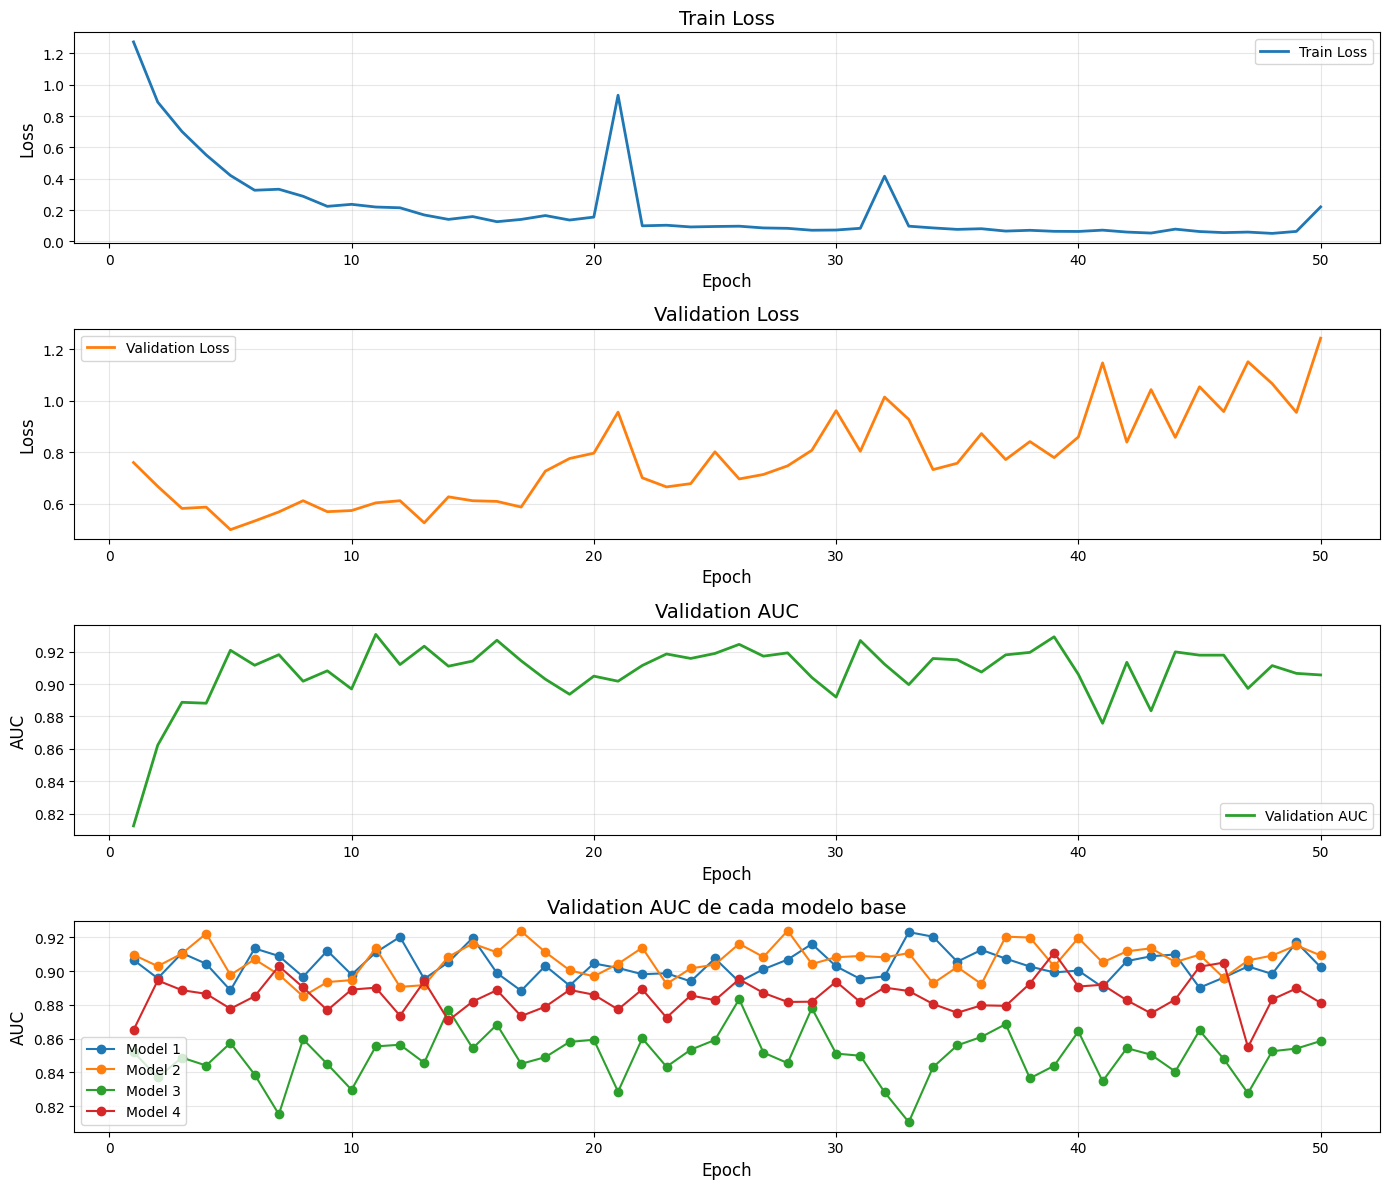

In [ ]:
train_loss = ensemble_class.history["train_loss"]
val_loss = ensemble_class.history["val_loss"]
val_auc = ensemble_class.history["val_auc"]
ensemble_model_aucs = ensemble_class.history.get("ensembles_val_auc", [])

epochs = np.arange(1, len(train_loss) + 1)

plt.figure(figsize=(14, 12))

# 1. TRAIN LOSS
plt.subplot(4, 1, 1)
plt.plot(epochs, train_loss, label="Train Loss", color="tab:blue", linewidth=2)
plt.title("Train Loss", fontsize=14)
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Loss", fontsize=12)
plt.grid(alpha=0.3)
plt.legend()

# 2. VALIDATION LOSS
plt.subplot(4, 1, 2)
plt.plot(epochs, val_loss, label="Validation Loss", color="tab:orange", linewidth=2)
plt.title("Validation Loss", fontsize=14)
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Loss", fontsize=12)
plt.grid(alpha=0.3)
plt.legend()

# 3. VALIDATION AUC
plt.subplot(4, 1, 3)
plt.plot(epochs, val_auc, label="Validation AUC", color="tab:green", linewidth=2)
plt.title("Validation AUC", fontsize=14)
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("AUC", fontsize=12)
plt.grid(alpha=0.3)
plt.legend()

plt.subplot(4, 1, 4)
if ensemble_model_aucs:
    ensemble_model_aucs = np.array(ensemble_model_aucs)  # shape [epochs, n_models]
    n_models = ensemble_model_aucs.shape[1]
    for i in range(n_models):
        plt.plot(epochs, ensemble_model_aucs[:, i], marker='o', label=f'Model {i+1}')
    plt.title("Validation AUC de cada modelo base", fontsize=14)
    plt.xlabel("Epoch", fontsize=12)
    plt.ylabel("AUC", fontsize=12)
    plt.grid(alpha=0.3)
    plt.legend()

plt.tight_layout()
plt.show()

### kaggle submission generation

In [ ]:
ensemble_class.submit_kaggle(test_loader, submission_file="submission.csv")

Inference on Test:   0%|          | 0/2 [00:00<?, ?it/s]


RuntimeError: mat1 and mat2 shapes cannot be multiplied (64x76 and 77x128)